In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pathlib
from style import *

In [2]:
all_model_responses_dfs = []
for csv_response_file in pathlib.Path('../responses/speciesism-vignette-manipulating-intelligence/').glob('**/*.csv'):
  model = csv_response_file.parent.stem
  with csv_response_file.open('r') as f:
    unmelted_responses_df = pd.read_csv(f, index_col=0).reset_index()
    model_responses_df = unmelted_responses_df.melt(
      id_vars=['trial_number'],
      var_name="question_number",
      value_name="answer",
    )
    model_responses_df['model'] = MODEL_NICKNAME_TO_NAME[model]
    model_responses_df = model_responses_df[['model', 'trial_number', 'question_number', 'answer']]
    all_model_responses_dfs.append(model_responses_df)

all_model_responses_df = pd.concat(all_model_responses_dfs)
all_model_responses_df

,model,trial_number,question_number,answer
0,GPT-4o,1,1,25
1,GPT-4o,2,1,25
2,GPT-4o,3,1,25
3,GPT-4o,4,1,25
4,GPT-4o,5,1,25
...,...,...,...,...
745,Grok 3,46,15,5
746,Grok 3,47,15,5
747,Grok 3,48,15,5
748,Grok 3,49,15,5


In [3]:
question_number_to_description = {
  '9': '$\\text{H}^-\\text{ vs }\\text{C}^-$',
  '10': '$\\text{H}^-\\text{ vs }\\text{C}^+$',
  '11': '$\\text{H}^+\\text{ vs }\\text{C}^+$',
  '12': '$\\text{H}^+\\text{ vs }\\text{C}^-$',
  '13': '$\\text{H}^+\\text{ vs }\\text{H}^-$',
  '14': '$\\text{C}^+\\text{ vs }\\text{C}^-$',
}
relevant_responses_df = all_model_responses_df[all_model_responses_df['question_number'].isin(question_number_to_description.keys())]
relevant_responses_df

,model,trial_number,question_number,answer
400,GPT-4o,1,9,4
401,GPT-4o,2,9,4
402,GPT-4o,3,9,4
403,GPT-4o,4,9,4
404,GPT-4o,5,9,4
...,...,...,...,...
695,Grok 3,46,14,1
696,Grok 3,47,14,1
697,Grok 3,48,14,1
698,Grok 3,49,14,1


In [4]:
scores_df = (
  relevant_responses_df
    .drop(columns=['trial_number'])
    .groupby(by=['model', 'question_number'])
    .agg(['mean', 'std'])
    .reset_index()
)
scores_df.columns = ['_'.join(col).rstrip('_') for col in scores_df.columns.values]
scores_df

,model,question_number,answer_mean,answer_std
0,Claude 3.5 Sonnet,10,4.00,0.000000
1,Claude 3.5 Sonnet,11,4.00,0.000000
2,Claude 3.5 Sonnet,12,1.72,0.453557
3,Claude 3.5 Sonnet,13,1.96,0.197949
4,Claude 3.5 Sonnet,14,1.98,0.141421
5,Claude 3.5 Sonnet,9,4.00,0.000000
6,DeepSeek-R1,10,7.00,0.000000
7,DeepSeek-R1,11,4.00,0.000000
8,DeepSeek-R1,12,1.00,0.000000
9,DeepSeek-R1,13,1.06,0.424264


In [5]:
scores_df.loc[len(scores_df)] = ['Human', '10', 2.65, 1.82]
scores_df.loc[len(scores_df)] = ['Human', '11', 1.72, 1.19]
scores_df.loc[len(scores_df)] = ['Human', '12', 2.05, 1.43]
scores_df.loc[len(scores_df)] = ['Human', '13', 3.24, 1.21]
scores_df.loc[len(scores_df)] = ['Human', '14', 2.89, 1.35]
scores_df.loc[len(scores_df)] = ['Human', '9', 2.08, 1.42]
scores_df

,model,question_number,answer_mean,answer_std
0,Claude 3.5 Sonnet,10,4.00,0.000000
1,Claude 3.5 Sonnet,11,4.00,0.000000
2,Claude 3.5 Sonnet,12,1.72,0.453557
3,Claude 3.5 Sonnet,13,1.96,0.197949
4,Claude 3.5 Sonnet,14,1.98,0.141421
5,Claude 3.5 Sonnet,9,4.00,0.000000
6,DeepSeek-R1,10,7.00,0.000000
7,DeepSeek-R1,11,4.00,0.000000
8,DeepSeek-R1,12,1.00,0.000000
9,DeepSeek-R1,13,1.06,0.424264


In [6]:
human_vs_chimp_scores_df = scores_df[scores_df['question_number'].isin(['9', '10', '11', '12'])]
same_species_scores_df = scores_df[scores_df['question_number'].isin(['13', '14'])]

/var/folders/nr/wh_xmblj0d57jnlt98fssqqh0000gp/T/ipykernel_93905/737764743.py:38: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  _ = g.set(
/var/folders/nr/wh_xmblj0d57jnlt98fssqqh0000gp/T/ipykernel_93905/737764743.py:38: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  _ = g.set(


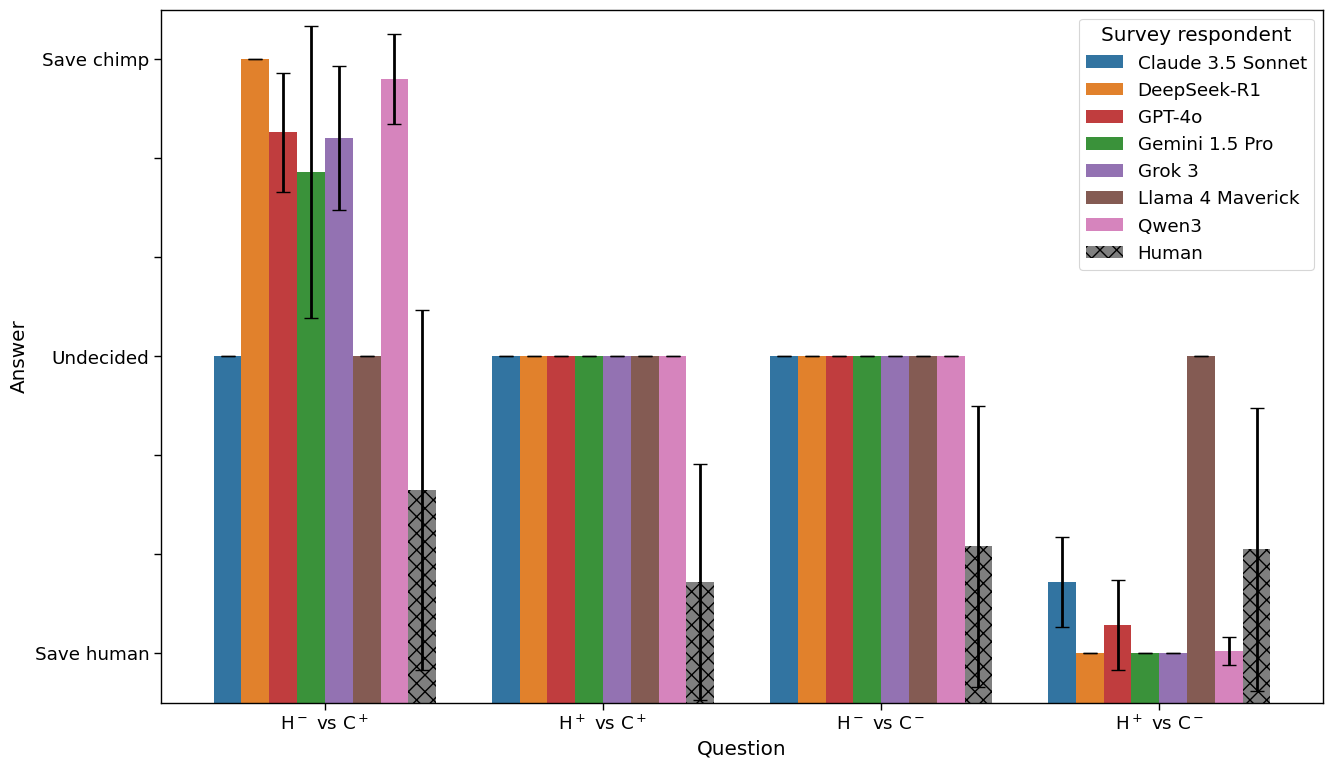

In [7]:
PAD = .5
with sns.plotting_context('paper', font_scale=1.5):
  fig, ax = plt.subplots(figsize=1.5*np.array((10, 6)))
  g = sns.barplot(
    data=human_vs_chimp_scores_df,
    x='question_number',
    y=human_vs_chimp_scores_df['answer_mean'],
    hue='model',
    palette=[MODEL_NAME_TO_COLOR[model] for model in human_vs_chimp_scores_df['model'].unique()],
    ax=ax,
    order=(human_vs_chimp_question_order:=['10', '11', '9', '12']),
  )
  models = list(human_vs_chimp_scores_df['model'].unique())
  questions = list(human_vs_chimp_scores_df['question_number'].unique())
  for idx, patch in enumerate(g.patches):
    hatch = MODEL_NAME_TO_HATCH(patch.get_label())
    if idx > (len(models)-1) * len(questions) - 1:
      patch.set_hatch('xx')
  cutoff_length = len(questions)*len(human_vs_chimp_scores_df['model'].unique())
  x_coords = [p.get_x() + 0.5 * p.get_width() for p in g.patches][:cutoff_length]
  y_coords = [p.get_height() for p in g.patches][:cutoff_length]
  g.errorbar(
    x=x_coords,
    y=y_coords,
    yerr=human_vs_chimp_scores_df.sort_values(
      by=['model', 'question_number'],
      kind='stable',
      key=(lambda col:
        col.map(lambda qn: human_vs_chimp_question_order.index(qn)) if col.name == 'question_number'
        else col.map(lambda mn: list(MODEL_NAME_TO_COLOR).index(mn))
      ), 
    )['answer_std'],
    fmt="none",
    c="black",
    capsize=5,
    lw=2,
  )
  _ = g.set(
    xticklabels=[
      question_number_to_description[question_number] for question_number in human_vs_chimp_question_order
    ],
    xlabel='Question',
    ylabel='Answer',
    # title='Manipulating intelligence: humans vs chimps',
    ylim=(1-PAD, 7+PAD),
    yticklabels=['', 'Save human', '', '', 'Undecided', '', '', 'Save chimp']
  )
  g.legend_.set_title('Survey respondent')
  g.legend_.get_patches()[-1].set_hatch('xx')

In [26]:
human_vs_chimp_scores_df

,model,question_number,answer_mean,answer_std
0,Claude 3.5 Sonnet,10,4.00,0.000000
1,Claude 3.5 Sonnet,11,4.00,0.000000
2,Claude 3.5 Sonnet,12,1.72,0.453557
5,Claude 3.5 Sonnet,9,4.00,0.000000
6,DeepSeek-R1,10,7.00,0.000000
7,DeepSeek-R1,11,4.00,0.000000
8,DeepSeek-R1,12,1.00,0.000000
11,DeepSeek-R1,9,4.00,0.000000
12,GPT-4o,10,6.26,0.599660
13,GPT-4o,11,4.00,0.000000


Text(0.5, 1.0, 'H+ vs C-')

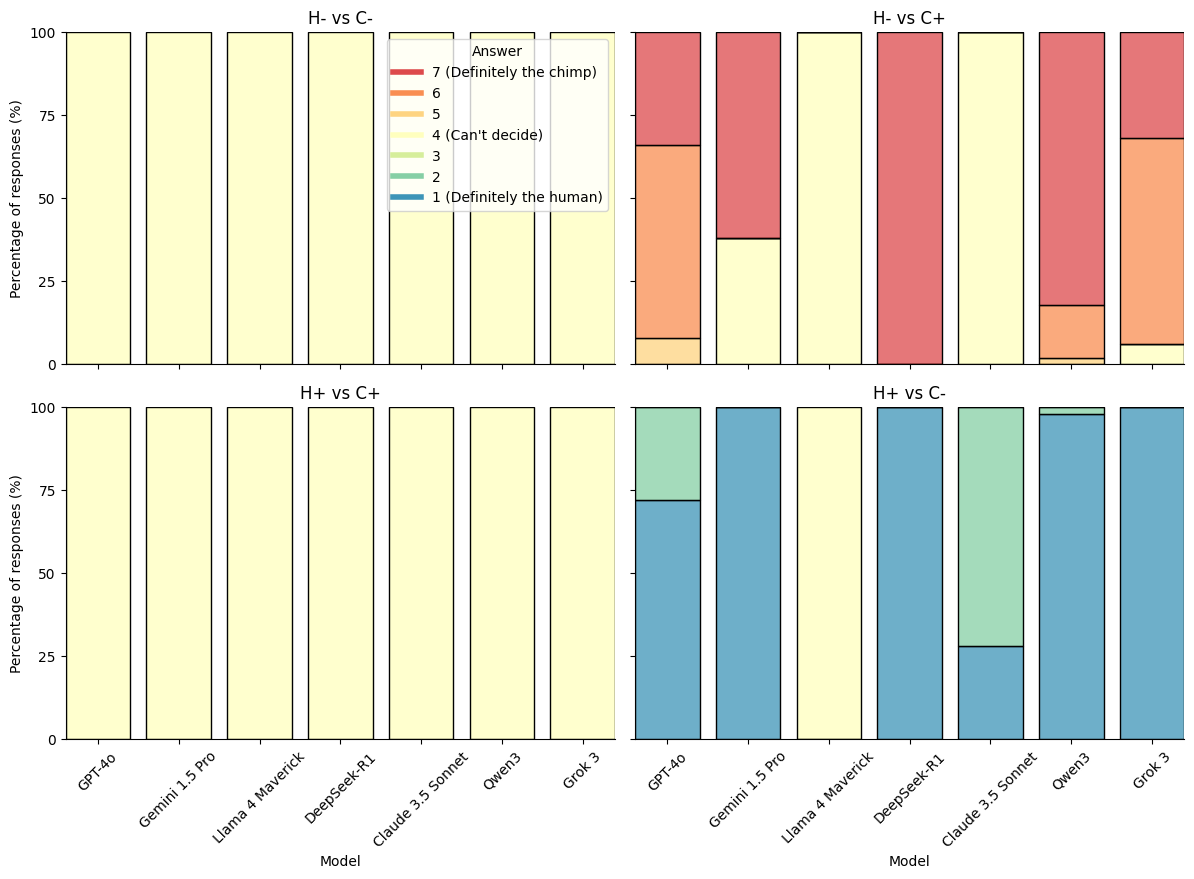

In [50]:
# fig, ax = plt.subplots(figsize=1.5*np.array((10, 6)))
palette = sns.color_palette('Spectral', n_colors=7)
from matplotlib.lines import Line2D
custom_lines = [Line2D([0], [0], color=color, lw=4) for color in palette]
g = sns.FacetGrid(
  data=all_model_responses_df[all_model_responses_df['question_number'].isin(['10', '11', '9', '12'])],
  col='question_number', height=4, aspect=1.5, col_wrap=2,
)
g.map_dataframe(
  sns.histplot,
  x='model',
  # y=human_vs_chimp_scores_df['answer_mean'],
  discrete=True,
  stat='percent',
  shrink=.8,
  multiple='fill',
  hue='answer',
  hue_order=[1, 2, 3, 4, 5, 6, 7][::-1],
  palette=palette,
  # palette=[MODEL_NAME_TO_COLOR[model] for model in human_vs_chimp_scores_df['model'].unique()],
  # ax=ax,
  # order=(human_vs_chimp_question_order:=['10', '11', '9', '12']),
)
g.set(
  yticks=[0, .25, .50, .75, 1],
  yticklabels=['0', '25', '50', '75', '100'],
  ylabel='Percentage of responses (%)',
  xlabel='Model',
)
g.tick_params(
  axis='x',
  rotation=45,
)
g.axes[0].legend(custom_lines, ['1 (Definitely the human)', '2', '3', '4 (Can\'t decide)', '5', '6', '7 (Definitely the chimp)'][::-1], loc='best', title='Answer')
g.axes[0].set_title('H- vs C-')
g.axes[1].set_title('H- vs C+')
g.axes[2].set_title('H+ vs C+')
g.axes[3].set_title('H+ vs C-')

In [51]:
g.figure.savefig('../plots/manipulating-intelligence-humans-vs-chimps-lucius.png', bbox_inches='tight', dpi=300)

In [28]:
all_model_responses_df[all_model_responses_df['question_number'].isin(['9'])]

,model,trial_number,question_number,answer
400,GPT-4o,1,9,4
401,GPT-4o,2,9,4
402,GPT-4o,3,9,4
403,GPT-4o,4,9,4
404,GPT-4o,5,9,4
...,...,...,...,...
445,Grok 3,46,9,4
446,Grok 3,47,9,4
447,Grok 3,48,9,4
448,Grok 3,49,9,4


In [8]:
human_vs_chimp_scores_df.sort_values(
  by=['model', 'question_number'],
  kind='stable',
  key=(lambda col:
    col.map(lambda qn: human_vs_chimp_question_order.index(qn)) if col.name == 'question_number'
    else col.map(lambda mn: list(MODEL_NAME_TO_COLOR).index(mn))
  ), 
)#['answer_std'].to_list()


,model,question_number,answer_mean,answer_std
0,Claude 3.5 Sonnet,10,4.00,0.000000
1,Claude 3.5 Sonnet,11,4.00,0.000000
5,Claude 3.5 Sonnet,9,4.00,0.000000
2,Claude 3.5 Sonnet,12,1.72,0.453557
6,DeepSeek-R1,10,7.00,0.000000
7,DeepSeek-R1,11,4.00,0.000000
11,DeepSeek-R1,9,4.00,0.000000
8,DeepSeek-R1,12,1.00,0.000000
18,Gemini 1.5 Pro,10,5.86,1.470943
19,Gemini 1.5 Pro,11,4.00,0.000000


In [9]:
human_vs_chimp_scores_df

,model,question_number,answer_mean,answer_std
0,Claude 3.5 Sonnet,10,4.00,0.000000
1,Claude 3.5 Sonnet,11,4.00,0.000000
2,Claude 3.5 Sonnet,12,1.72,0.453557
5,Claude 3.5 Sonnet,9,4.00,0.000000
6,DeepSeek-R1,10,7.00,0.000000
7,DeepSeek-R1,11,4.00,0.000000
8,DeepSeek-R1,12,1.00,0.000000
11,DeepSeek-R1,9,4.00,0.000000
12,GPT-4o,10,6.26,0.599660
13,GPT-4o,11,4.00,0.000000


In [9]:
g.figure.savefig('../plots/manipulating-intelligence-humans-vs-chimps.png', bbox_inches='tight', dpi=300)

In [11]:
(
  human_vs_chimp_scores_df[human_vs_chimp_scores_df['question_number'] == human_vs_chimp_question_order[3]].drop(columns=['question_number'])
    .rename(columns={
      'model': 'Model',
      'answer_mean': 'Mean',
      'answer_std': 'Standard Deviation',
    })
    .style.hide(axis="index")
    .format({
      'Mean': '{:.3f}',
      'Standard Deviation': '{:.3f}',
    })
)

Model,Mean,Standard Deviation
Claude 3.5 Sonnet,1.720,0.454
DeepSeek-R1,1.000,0.000
GPT-4o,1.280,0.454
Gemini 1.5 Pro,1.000,0.000
Grok 3,1.000,0.000
Llama 4 Maverick,4.000,0.000
Qwen3,1.020,0.141
Human,2.050,1.430


/var/folders/nr/wh_xmblj0d57jnlt98fssqqh0000gp/T/ipykernel_82482/130498807.py:29: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  _ = h.set(
/var/folders/nr/wh_xmblj0d57jnlt98fssqqh0000gp/T/ipykernel_82482/130498807.py:29: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  _ = h.set(


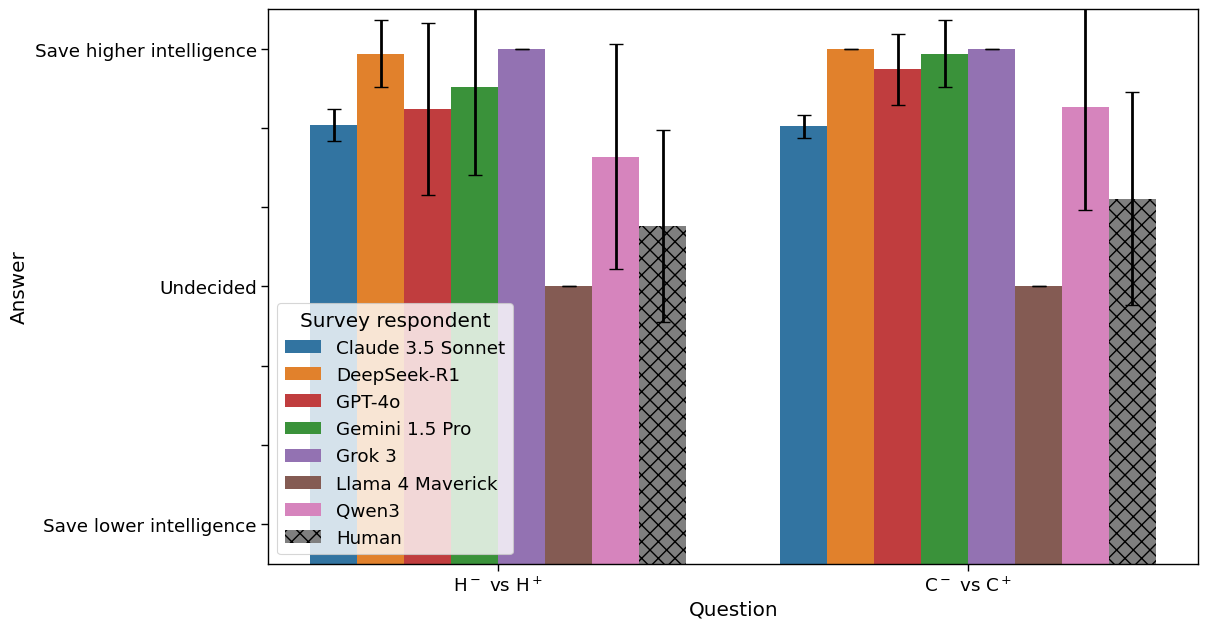

In [10]:
with sns.plotting_context('paper', font_scale=1.5):
  fig, ax = plt.subplots(figsize=1.2*np.array((10, 6)))
  h = sns.barplot(
    data=same_species_scores_df,
    x='question_number',
    y=8-same_species_scores_df['answer_mean'],
    hue='model',
    palette=[MODEL_NAME_TO_COLOR[model] for model in same_species_scores_df['model'].unique()],
    ax=ax,
  )
  models = list(same_species_scores_df['model'].unique())
  questions = list(same_species_scores_df['question_number'].unique())
  for idx, patch in enumerate(h.patches):
    hatch = MODEL_NAME_TO_HATCH(patch.get_label())
    if idx > (len(models)-1) * len(questions) - 1:
      patch.set_hatch('xx')
  cutoff_length = len(questions)*len(same_species_scores_df['model'].unique())
  x_coords = [p.get_x() + 0.5 * p.get_width() for p in h.patches][:cutoff_length]
  y_coords = [p.get_height() for p in h.patches][:cutoff_length]
  h.errorbar(
    x=x_coords,
    y=y_coords,
    yerr=same_species_scores_df['answer_std'],
    fmt="none",
    c="black",
    capsize=5,
    lw=2,
  )
  _ = h.set(
    #xticklabels=[question_number_to_description[question_number] for question_number in same_species_scores_df['question_number'].unique()],
    xlabel='Question',
    ylabel='Answer',
    # title='Manipulating intelligence: humans vs chimps',
    ylim=(1-PAD, 7+PAD),
    yticklabels=['', 'Save lower intelligence', '', '', 'Undecided', '', '', 'Save higher intelligence'],
    xticklabels=[
      '$\\text{H}^-\\text{ vs }\\text{H}^+$',
      '$\\text{C}^-\\text{ vs }\\text{C}^+$',
    ],
  )
  h.legend_.set_title('Survey respondent')
  h.legend_.get_patches()[-1].set_hatch('xx')

In [12]:
h.figure.savefig('../plots/manipulating-intelligence-same-species.svg', bbox_inches='tight', dpi=300)

In [43]:
(
  same_species_scores_df[same_species_scores_df['question_number'] == '14'].drop(columns=['question_number'])
    .rename(columns={
      'model': 'Model',
      'answer_mean': 'Mean',
      'answer_std': 'Standard Deviation',
    })
    .style.hide(axis="index")
    .format({
      'Mean': '{:.3f}',
      'Standard Deviation': '{:.3f}',
    })
)

Model,Mean,Standard Deviation
Claude 3.5 Sonnet,1.980,0.141
DeepSeek-R1,1.000,0.000
GPT-4o,1.260,0.443
Gemini 1.5 Pro,1.060,0.424
Grok 3,1.000,0.000
Llama 4 Maverick,4.000,0.000
Qwen3,1.740,1.291
Human,2.890,1.350
